# UNSW-NB15 — C5 Confidence Calibration Multi-Run (Statevector, C=1.0)

**Mục tiêu (1.7):** Đo metric NGOÀI F1 cho QSVM vs classical (linear/poly/rbf) trên UNSW: **confidence calibration (ECE rare)** + **rare-class precision/recall (AUC-PR rare)** + **margin advantage (Cohen's d)**. Kiểm tra QSVM có advantage angle nào ngoài F1 không (theo template NSL-KDD C5: QSVM ECE_rare=0.434 < RBF=0.471).

**Rare categories UNSW** (5 mẫu/cat × 4 cats × 5 runs = 100 rare): `Analysis`, `Backdoor`, `Shellcode`, `Worms`.

**Pipeline mỗi run (zero-leakage):** `parquet (186 features) → SelectKBest(K=35) → PCA(n=4) → MinMax[0,π] → SVC(kernel='precomputed', probability=True, C=1.0)`

**Cache reuse (CỐT LÕI):** Reuse K_quantum_{train,test}_train từ `models_unsw/qsvm_cache/multirun/run_{i}/` (1.4a cache). KHÔNG re-compute quantum.

**Outputs:**
- `models_unsw/c5_results.json` — schema theo spec 1.7
- 4 PNG: `c5_{calibration_curves, auc_pr_curves, margin_distribution, per_group_accuracy}.png`


## 1. Config & Imports

In [1]:
import os, json, time, warnings, datetime
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
warnings.filterwarnings('ignore')

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    confusion_matrix, average_precision_score, precision_recall_curve,
)
from scipy.stats import binomtest, gaussian_kde

# Quantum (chỉ dùng để load cache — KHÔNG re-compute)
# Note: không import qiskit vì cache đã có dưới dạng .npy
print('Imports OK')


Imports OK


In [2]:
# ── Hằng số toàn cục ───────────────────────────────────────────────
RANDOM_STATE = 42
RUN_IDS      = [1, 2, 3, 4, 5]
np.random.seed(RANDOM_STATE)

# Pipeline (khớp 1.3 / 1.4a / 1.5 — để cache hit)
N_QUBITS  = 4
K_SELECT  = 35
PCA_N     = 4
ANGLE_MAX = np.pi

# Classical kernel params (khớp SVC defaults — gamma='scale', coef0=0)
POLY_DEGREE = 2

# Target & label cols
TARGET_COL  = 'label_binary'
LABEL_COLS  = ['label_binary', 'label_multiclass', 'attack_category']
CAT_COL     = 'attack_category'

# Rare categories UNSW (5 mẫu/cat/run × 5 runs = 25 mẫu/cat tổng)
RARE_CATS = ['Analysis', 'Backdoor', 'Shellcode', 'Worms']

# Paths (notebook chạy ở notebooks_unsw/)
DATA_DIR        = '../data/unsw_nb15/processed_data/multi_run'
MODELS_DIR      = '../models_unsw'
MULTIRUN_CACHE  = f'{MODELS_DIR}/qsvm_cache/multirun'   # 1.4a — REUSE
REPORTS_DIR     = '../reports_unsw'
RESULTS_JSON    = f'{MODELS_DIR}/c5_results.json'
NSL_C5_JSON     = '../data/processed_data/c5_results.json'  # cho bonus comparison

# Kernel names + display
KERNEL_NAMES  = ['quantum', 'linear', 'poly', 'rbf']
DISPLAY_NAMES = {'quantum':'QSVM (ZZ)', 'linear':'SVM-Linear',
                 'poly':'SVM-Poly2',    'rbf':'SVM-RBF'}
COLORS        = {'quantum':'#1565C0', 'linear':'#E53935',
                 'poly':'#43A047',    'rbf':'#8E24AA'}

# Config tag (khớp 1.3 / 1.4a / 1.5)
CONFIG_TAG  = 'r2_full_k35_p4_cv5_sf1_run1'
C_STRATEGY  = 'neutral_C1_no_retune'
C_BY_KERNEL = {k: 1.0 for k in KERNEL_NAMES}

# ECE binning
ECE_N_BINS = 10

os.makedirs(REPORTS_DIR, exist_ok=True)

print(f'CONFIG_TAG : {CONFIG_TAG}')
print(f'C_STRATEGY : {C_STRATEGY}')
print(f'RARE_CATS  : {RARE_CATS}')
print(f'CACHE      : {MULTIRUN_CACHE}  (1.4a — REUSE)')


CONFIG_TAG : r2_full_k35_p4_cv5_sf1_run1
C_STRATEGY : neutral_C1_no_retune
RARE_CATS  : ['Analysis', 'Backdoor', 'Shellcode', 'Worms']
CACHE      : ../models_unsw/qsvm_cache/multirun  (1.4a — REUSE)


## 2. Helpers — Pipeline, KTA, ECE adaptive, Cohen's d, McNemar

In [3]:
def fit_pipeline_per_run(X_train_raw, y_train):
    """Fit SelectKBest -> PCA -> MinMax CHỈ trên train (zero-leakage)."""
    selector = SelectKBest(f_classif, k=K_SELECT).fit(X_train_raw, y_train)
    X_train_sel = selector.transform(X_train_raw)
    pca = PCA(n_components=PCA_N, random_state=RANDOM_STATE).fit(X_train_sel)
    X_train_pca = pca.transform(X_train_sel)
    scaler = MinMaxScaler(feature_range=(0.0, ANGLE_MAX)).fit(X_train_pca)
    return selector, pca, scaler

def apply_pipeline(X_raw, selector, pca, scaler):
    X_sel = selector.transform(X_raw)
    X_pca = pca.transform(X_sel)
    return np.clip(scaler.transform(X_pca), 0.0, ANGLE_MAX).astype(np.float64)

def load_K_quantum_strict(rid):
    """Load K_train_train + K_test_train từ multirun cache. FAIL nếu miss."""
    p_tr = f'{MULTIRUN_CACHE}/run_{rid}/K_quantum_train_train_{CONFIG_TAG}.npy'
    p_te = f'{MULTIRUN_CACHE}/run_{rid}/K_quantum_test_train_{CONFIG_TAG}.npy'
    for p in (p_tr, p_te):
        if not os.path.exists(p):
            raise FileNotFoundError(f'[CACHE MISS] {p} — 1.7 phải reuse cache 1.4a')
    return np.load(p_tr), np.load(p_te)

def classical_K(X_train, X_test, kernel_name):
    """Tính K_train_train + K_test_train cho linear/poly/rbf khớp SVC defaults."""
    if kernel_name == 'linear':
        return X_train @ X_train.T, X_test @ X_train.T
    n_feat = X_train.shape[1]
    var_X  = X_train.var()
    gamma  = 1.0 / (n_feat * var_X) if var_X > 0 else 1.0 / n_feat
    if kernel_name == 'poly':
        return (gamma * (X_train @ X_train.T)) ** POLY_DEGREE, \
               (gamma * (X_test  @ X_train.T)) ** POLY_DEGREE
    if kernel_name == 'rbf':
        sq_tr = np.sum(X_train**2, axis=1)
        D_tr  = sq_tr[:, None] + sq_tr[None, :] - 2 * (X_train @ X_train.T)
        D_te  = np.sum(X_test**2, axis=1)[:, None] + sq_tr[None, :] - 2 * (X_test @ X_train.T)
        return np.exp(-gamma * np.maximum(D_tr, 0)), np.exp(-gamma * np.maximum(D_te, 0))
    raise ValueError(kernel_name)

def adaptive_calibration_curve(y_true, y_prob, n_bins=10):
    """Equal-frequency binning. Trả về (mean_conf, frac_pos, bin_sizes)."""
    n = len(y_prob)
    if n == 0:
        return np.array([]), np.array([]), np.array([])
    sorted_idx = np.argsort(y_prob)
    yp_sorted = y_prob[sorted_idx]
    yt_sorted = y_true[sorted_idx]
    bin_size = max(n // n_bins, 1)
    mean_conf, frac_pos, bin_sizes = [], [], []
    for i in range(n_bins):
        start = i * bin_size
        end   = (i + 1) * bin_size if i < n_bins - 1 else n
        if start >= n: break
        bt = yt_sorted[start:end]
        bp = yp_sorted[start:end]
        if len(bt) == 0: continue
        mean_conf.append(float(np.mean(bp)))
        frac_pos.append(float(np.mean(bt)))
        bin_sizes.append(len(bt))
    return np.array(mean_conf), np.array(frac_pos), np.array(bin_sizes)

def compute_ece(y_true, y_prob, n_bins=10):
    """ECE = Σ |bin|/n · |frac_pos - mean_conf|."""
    mc, fp, bs = adaptive_calibration_curve(y_true, y_prob, n_bins)
    if len(mc) == 0:
        return float('nan')
    n = len(y_true)
    return float(np.sum(bs / n * np.abs(fp - mc)))

def cohens_d(a, b):
    """Cohen's d với pooled std. d>0: mean(a)>mean(b)."""
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    if len(a) < 2 or len(b) < 2:
        return float('nan')
    pooled = np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2) / 2.0)
    if pooled < 1e-12:
        return float('nan')
    return float((a.mean() - b.mean()) / pooled)

def mcnemar_exact(y_true, y_pred_a, y_pred_b):
    """Exact binomial McNemar 2-sided. Trả về (b, c, p_value).
    b = A sai & B đúng, c = A đúng & B sai (convention 1.4a-redo).
    """
    a_correct = (y_pred_a == y_true)
    b_correct = (y_pred_b == y_true)
    b = int(np.sum((~a_correct) & b_correct))
    c = int(np.sum(a_correct & (~b_correct)))
    if b + c == 0:
        return b, c, 1.0
    return b, c, float(binomtest(min(b, c), n=b+c, p=0.5).pvalue)

def cohens_d_interpretation(d):
    if np.isnan(d): return 'undefined'
    ad = abs(d)
    sign = 'QSVM > RBF' if d > 0 else 'RBF > QSVM'
    if ad < 0.2:  size = 'negligible'
    elif ad < 0.5: size = 'small'
    elif ad < 0.8: size = 'medium'
    else: size = 'large'
    return f'{size} ({sign})'

print('Helpers ready.')


Helpers ready.


## 3. Single-run logic: 4 SVCs probability=True, compute metrics + margin

In [4]:
def run_c5_single(rid):
    """Chạy 4 kernels trên cặp parquet run_{rid}. Trả về dict per-run."""
    print(f'\n[C5][run_{rid}] ====== START ======')

    df_train = pd.read_parquet(f'{DATA_DIR}/train_run{rid}.parquet')
    df_test  = pd.read_parquet(f'{DATA_DIR}/test_run{rid}.parquet')
    feat_cols = [c for c in df_train.columns if c not in LABEL_COLS]
    X_train_raw = df_train[feat_cols].to_numpy(dtype=np.float64)
    y_train     = df_train[TARGET_COL].to_numpy(dtype=np.int64)
    X_test_raw  = df_test[feat_cols].to_numpy(dtype=np.float64)
    y_test      = df_test[TARGET_COL].to_numpy(dtype=np.int64)
    cat_test    = df_test[CAT_COL].to_numpy()

    # Rare mask: position-based mask trên test_run{rid}
    rare_mask = np.isin(cat_test, RARE_CATS)
    n_rare = int(rare_mask.sum())
    print(f'  Train: {X_train_raw.shape} y={dict(zip(*np.unique(y_train, return_counts=True)))}')
    print(f'  Test : {X_test_raw.shape}  rare_mask sum={n_rare} (expect 20)')

    # Pipeline zero-leakage
    selector, pca, scaler = fit_pipeline_per_run(X_train_raw, y_train)
    X_train = apply_pipeline(X_train_raw, selector, pca, scaler)
    X_test  = apply_pipeline(X_test_raw,  selector, pca, scaler)

    # Kernel matrices: quantum từ cache, classical fresh
    K_q_tr, K_q_te = load_K_quantum_strict(rid)
    print(f'  [CACHE HIT] quantum: K_tr={K_q_tr.shape}, K_te={K_q_te.shape}')

    K_train_by_kernel = {'quantum': K_q_tr}
    K_test_by_kernel  = {'quantum': K_q_te}
    for k in ['linear', 'poly', 'rbf']:
        K_tr, K_te = classical_K(X_train, X_test, k)
        K_train_by_kernel[k] = K_tr
        K_test_by_kernel[k]  = K_te

    # Fit 4 SVCs với probability=True (Platt internal CV)
    per_kernel = {}
    for k in KERNEL_NAMES:
        t0 = time.time()
        clf = SVC(kernel='precomputed', C=C_BY_KERNEL[k],
                  probability=True, random_state=RANDOM_STATE)
        clf.fit(K_train_by_kernel[k], y_train)
        y_pred = clf.predict(K_test_by_kernel[k])
        prob   = clf.predict_proba(K_test_by_kernel[k])[:, 1]  # P(attack)
        margin = clf.decision_function(K_test_by_kernel[k])
        elapsed = time.time() - t0

        # AUC-PR overall (binary attack/normal)
        auc_pr_overall = float(average_precision_score(y_test, prob))
        # AUC-PR rare (y_true=1 if rare attack else 0; score=prob_attack)
        y_rare_membership = rare_mask.astype(int)
        auc_pr_rare = float(average_precision_score(y_rare_membership, prob))

        # ECE rare (y_true=label_binary[rare] which is all 1 for rare; prob[rare])
        # → ECE = mean(1 - prob_rare), nhưng adaptive binning vẫn dùng:
        if n_rare >= 2:
            ece_rare = compute_ece(y_test[rare_mask], prob[rare_mask], n_bins=ECE_N_BINS)
        else:
            ece_rare = float('nan')

        # Per-group accuracy (trên 4 rare cats)
        per_group_acc = {}
        for cat in RARE_CATS:
            mask_cat = (cat_test == cat)
            if mask_cat.sum() > 0:
                per_group_acc[cat] = float(accuracy_score(y_test[mask_cat], y_pred[mask_cat]))
            else:
                per_group_acc[cat] = float('nan')

        # Rare margin (|decision_function| trên rare samples)
        rare_margin = np.abs(margin[rare_mask]) if n_rare > 0 else np.array([])

        per_kernel[k] = {
            'C':              float(C_BY_KERNEL[k]),
            'f1':             float(f1_score(y_test, y_pred, average='binary')),
            'precision':      float(precision_score(y_test, y_pred, average='binary', zero_division=0)),
            'recall':         float(recall_score(y_test, y_pred, average='binary', zero_division=0)),
            'accuracy':       float(accuracy_score(y_test, y_pred)),
            'ece_rare':       ece_rare,
            'auc_pr_overall': auc_pr_overall,
            'auc_pr_rare':    auc_pr_rare,
            'per_group_acc':  per_group_acc,
            'rare_margin_mean': float(rare_margin.mean()) if len(rare_margin) > 0 else float('nan'),
            'rare_margin_std':  float(rare_margin.std())  if len(rare_margin) > 1 else float('nan'),
            'n_rare_test':    n_rare,
            'rare_margin':    rare_margin.tolist(),  # cho Cohen's d pooled
            'y_pred':         y_pred.astype(int).tolist(),
            'prob':           prob.tolist(),
            'fit_sec':        round(elapsed, 2),
        }
        print(f'  [{k:>7s}] fit={elapsed:.2f}s | f1={per_kernel[k]["f1"]:.4f} '
              f'ece_rare={per_kernel[k]["ece_rare"]:.4f} '
              f'auc_pr_rare={per_kernel[k]["auc_pr_rare"]:.4f}')

    return {
        'run_id':     int(rid),
        'y_test':     y_test.astype(int).tolist(),
        'cat_test':   cat_test.tolist(),
        'rare_mask':  rare_mask.astype(int).tolist(),
        'per_kernel': per_kernel,
    }


## 4. Run 5 runs & aggregate

In [5]:
t_start = time.time()
all_results = {}
for rid in RUN_IDS:
    all_results[rid] = run_c5_single(rid)
print(f'\n=== ALL {len(RUN_IDS)} RUNS DONE in {time.time()-t_start:.1f}s ===')



[C5][run_1] ====== START ======


  Train: (100, 186) y={np.int64(0): np.int64(26), np.int64(1): np.int64(74)}
  Test : (100, 186)  rare_mask sum=20 (expect 20)
  [CACHE HIT] quantum: K_tr=(100, 100), K_te=(100, 100)
  [quantum] fit=0.00s | f1=0.7950 ece_rare=0.2103 auc_pr_rare=0.4052
  [ linear] fit=0.00s | f1=0.8205 ece_rare=0.1321 auc_pr_rare=0.3406
  [   poly] fit=0.00s | f1=0.7950 ece_rare=0.1360 auc_pr_rare=0.4341
  [    rbf] fit=0.00s | f1=0.7950 ece_rare=0.2113 auc_pr_rare=0.2855

[C5][run_2] ====== START ======
  Train: (100, 186) y={np.int64(0): np.int64(26), np.int64(1): np.int64(74)}
  Test : (100, 186)  rare_mask sum=20 (expect 20)
  [CACHE HIT] quantum: K_tr=(100, 100), K_te=(100, 100)
  [quantum] fit=0.00s | f1=0.7692 ece_rare=0.2334 auc_pr_rare=0.2574
  [ linear] fit=0.00s | f1=0.7717 ece_rare=0.2375 auc_pr_rare=0.3119
  [   poly] fit=0.00s | f1=0.7717 ece_rare=0.2244 auc_pr_rare=0.5151
  [    rbf] fit=0.00s | f1=0.7717 ece_rare=0.2440 auc_pr_rare=0.2595

[C5][run_3] ====== START ======
  Train: (100, 1

  Train: (100, 186) y={np.int64(0): np.int64(26), np.int64(1): np.int64(74)}
  Test : (100, 186)  rare_mask sum=20 (expect 20)
  [CACHE HIT] quantum: K_tr=(100, 100), K_te=(100, 100)
  [quantum] fit=0.00s | f1=0.7922 ece_rare=0.1054 auc_pr_rare=0.4205
  [ linear] fit=0.00s | f1=0.8182 ece_rare=0.1411 auc_pr_rare=0.3782
  [   poly] fit=0.01s | f1=0.8077 ece_rare=0.1558 auc_pr_rare=0.4223
  [    rbf] fit=0.00s | f1=0.8077 ece_rare=0.1622 auc_pr_rare=0.2354

[C5][run_5] ====== START ======
  Train: (100, 186) y={np.int64(0): np.int64(26), np.int64(1): np.int64(74)}
  Test : (100, 186)  rare_mask sum=20 (expect 20)
  [CACHE HIT] quantum: K_tr=(100, 100), K_te=(100, 100)
  [quantum] fit=0.00s | f1=0.8296 ece_rare=0.2320 auc_pr_rare=0.3711
  [ linear] fit=0.00s | f1=0.8305 ece_rare=0.1910 auc_pr_rare=0.4026
  [   poly] fit=0.00s | f1=0.8189 ece_rare=0.2157 auc_pr_rare=0.3807
  [    rbf] fit=0.00s | f1=0.8305 ece_rare=0.2085 auc_pr_rare=0.2064

=== ALL 5 RUNS DONE in 1.0s ===


## 5. Aggregate mean ± std (5 runs × 4 kernels)

In [6]:
rows = []
for rid, res in all_results.items():
    for k in KERNEL_NAMES:
        m = res['per_kernel'][k]
        rows.append({
            'run': rid, 'kernel': k,
            'f1': m['f1'], 'precision': m['precision'], 'recall': m['recall'],
            'accuracy': m['accuracy'], 'ece_rare': m['ece_rare'],
            'auc_pr_overall': m['auc_pr_overall'], 'auc_pr_rare': m['auc_pr_rare'],
            'rare_margin_mean': m['rare_margin_mean'],
        })
per_run_df = pd.DataFrame(rows)

# Summary per kernel
summary = {}
for k in KERNEL_NAMES:
    sub = per_run_df[per_run_df['kernel'] == k]
    # Per-group acc mean across runs
    per_group_acc_mean = {}
    for cat in RARE_CATS:
        vals = [all_results[rid]['per_kernel'][k]['per_group_acc'][cat]
                for rid in RUN_IDS if not np.isnan(all_results[rid]['per_kernel'][k]['per_group_acc'][cat])]
        per_group_acc_mean[cat] = float(np.mean(vals)) if vals else float('nan')
    summary[k] = {
        'f1_mean':              float(sub['f1'].mean()),
        'f1_std':               float(sub['f1'].std()),
        'ece_rare_mean':        float(sub['ece_rare'].mean()),
        'ece_rare_std':         float(sub['ece_rare'].std()),
        'auc_pr_overall_mean': float(sub['auc_pr_overall'].mean()),
        'auc_pr_overall_std':  float(sub['auc_pr_overall'].std()),
        'auc_pr_rare_mean':    float(sub['auc_pr_rare'].mean()),
        'auc_pr_rare_std':     float(sub['auc_pr_rare'].std()),
        'rare_margin_mean':    float(sub['rare_margin_mean'].mean()),
        'per_group_acc_mean':  per_group_acc_mean,
        'C':                   float(C_BY_KERNEL[k]),
    }

print('=== Summary per kernel (mean ± std over 5 runs) ===')
print(f'{"Kernel":>8}  {"F1":>16}  {"ECE_rare":>16}  {"AUC-PR_rare":>16}  {"AUC-PR_all":>16}')
print('-' * 80)
for k in KERNEL_NAMES:
    s = summary[k]
    print(f'{k:>8}  {s["f1_mean"]:.4f}±{s["f1_std"]:.3f}  '
          f'{s["ece_rare_mean"]:.4f}±{s["ece_rare_std"]:.3f}  '
          f'{s["auc_pr_rare_mean"]:.4f}±{s["auc_pr_rare_std"]:.3f}  '
          f'{s["auc_pr_overall_mean"]:.4f}±{s["auc_pr_overall_std"]:.3f}')


=== Summary per kernel (mean ± std over 5 runs) ===
  Kernel                F1          ECE_rare       AUC-PR_rare        AUC-PR_all
--------------------------------------------------------------------------------
 quantum  0.7977±0.022  0.1935±0.053  0.3355±0.089  0.8651±0.038
  linear  0.8129±0.024  0.1824±0.045  0.3449±0.046  0.8935±0.022
    poly  0.7971±0.018  0.1928±0.044  0.4079±0.083  0.8853±0.024
     rbf  0.8015±0.021  0.2047±0.029  0.2463±0.029  0.8582±0.071


## 6. Figure 1 — Calibration curves (reliability diagram, rare only, 4 kernels)

Pool predictions across 5 runs (n_rare_total=100), compute adaptive curve mỗi kernel.

Saved: ../reports_unsw/c5_calibration_curves.png


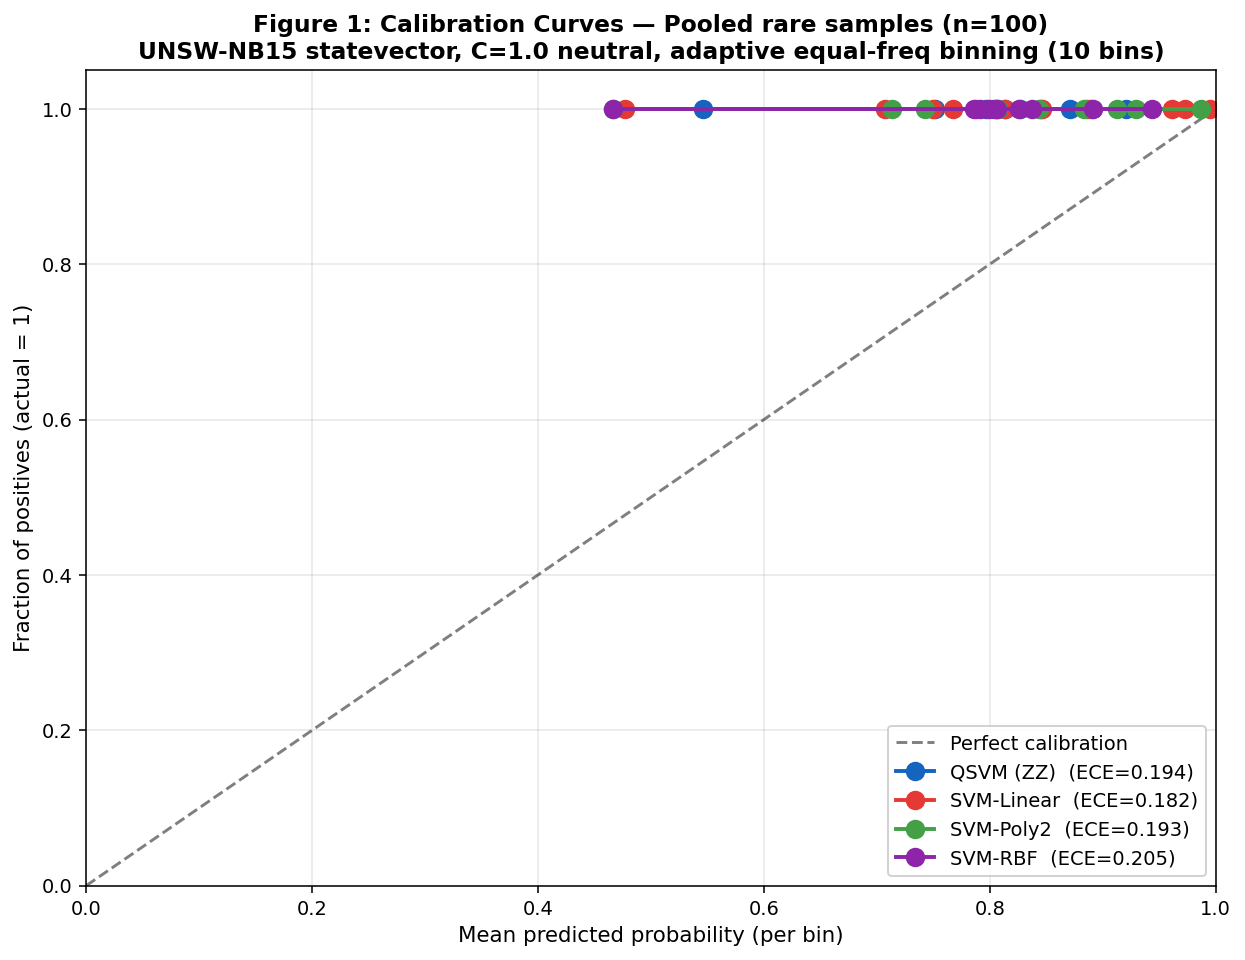

In [7]:
# Pool rare predictions across 5 runs
pooled_rare = {k: {'y_true': [], 'y_prob': []} for k in KERNEL_NAMES}
for rid in RUN_IDS:
    res = all_results[rid]
    mask = np.array(res['rare_mask'], dtype=bool)
    y_t  = np.array(res['y_test'])[mask]  # rare samples all label=1
    for k in KERNEL_NAMES:
        prob = np.array(res['per_kernel'][k]['prob'])[mask]
        pooled_rare[k]['y_true'].extend(y_t.tolist())
        pooled_rare[k]['y_prob'].extend(prob.tolist())

fig1, ax1 = plt.subplots(figsize=(9, 7))
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')

for k in KERNEL_NAMES:
    y_t = np.array(pooled_rare[k]['y_true'])
    y_p = np.array(pooled_rare[k]['y_prob'])
    mc, fp, bs = adaptive_calibration_curve(y_t, y_p, n_bins=ECE_N_BINS)
    ece_pool = float(np.sum(bs / len(y_t) * np.abs(fp - mc))) if len(mc) > 0 else float('nan')
    if len(mc) > 0:
        ax1.plot(mc, fp, marker='o', markersize=9, linewidth=2,
                 color=COLORS[k], label=f'{DISPLAY_NAMES[k]}  (ECE={ece_pool:.3f})')

ax1.set_xlabel('Mean predicted probability (per bin)', fontsize=11)
ax1.set_ylabel('Fraction of positives (actual = 1)', fontsize=11)
ax1.set_title(f'Figure 1: Calibration Curves — Pooled rare samples (n={len(pooled_rare["quantum"]["y_true"])})\n'
              f'UNSW-NB15 statevector, C=1.0 neutral, adaptive equal-freq binning ({ECE_N_BINS} bins)',
              fontsize=12, fontweight='bold')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1.05)
ax1.legend(loc='lower right', framealpha=0.9, fontsize=10)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
fig1_path = f'{REPORTS_DIR}/c5_calibration_curves.png'
fig1.savefig(fig1_path, dpi=140, bbox_inches='tight')
plt.close(fig1)
print(f'Saved: {fig1_path}')
display(Image(fig1_path))


## 7. Figure 2 — AUC-PR curves (overall + rare-membership, 4 kernels)

Left: AUC-PR binary (attack vs normal) trên full test pooled. Right: AUC-PR rare-membership (y=1 if rare cat else 0) trên full test pooled.

Saved: ../reports_unsw/c5_auc_pr_curves.png


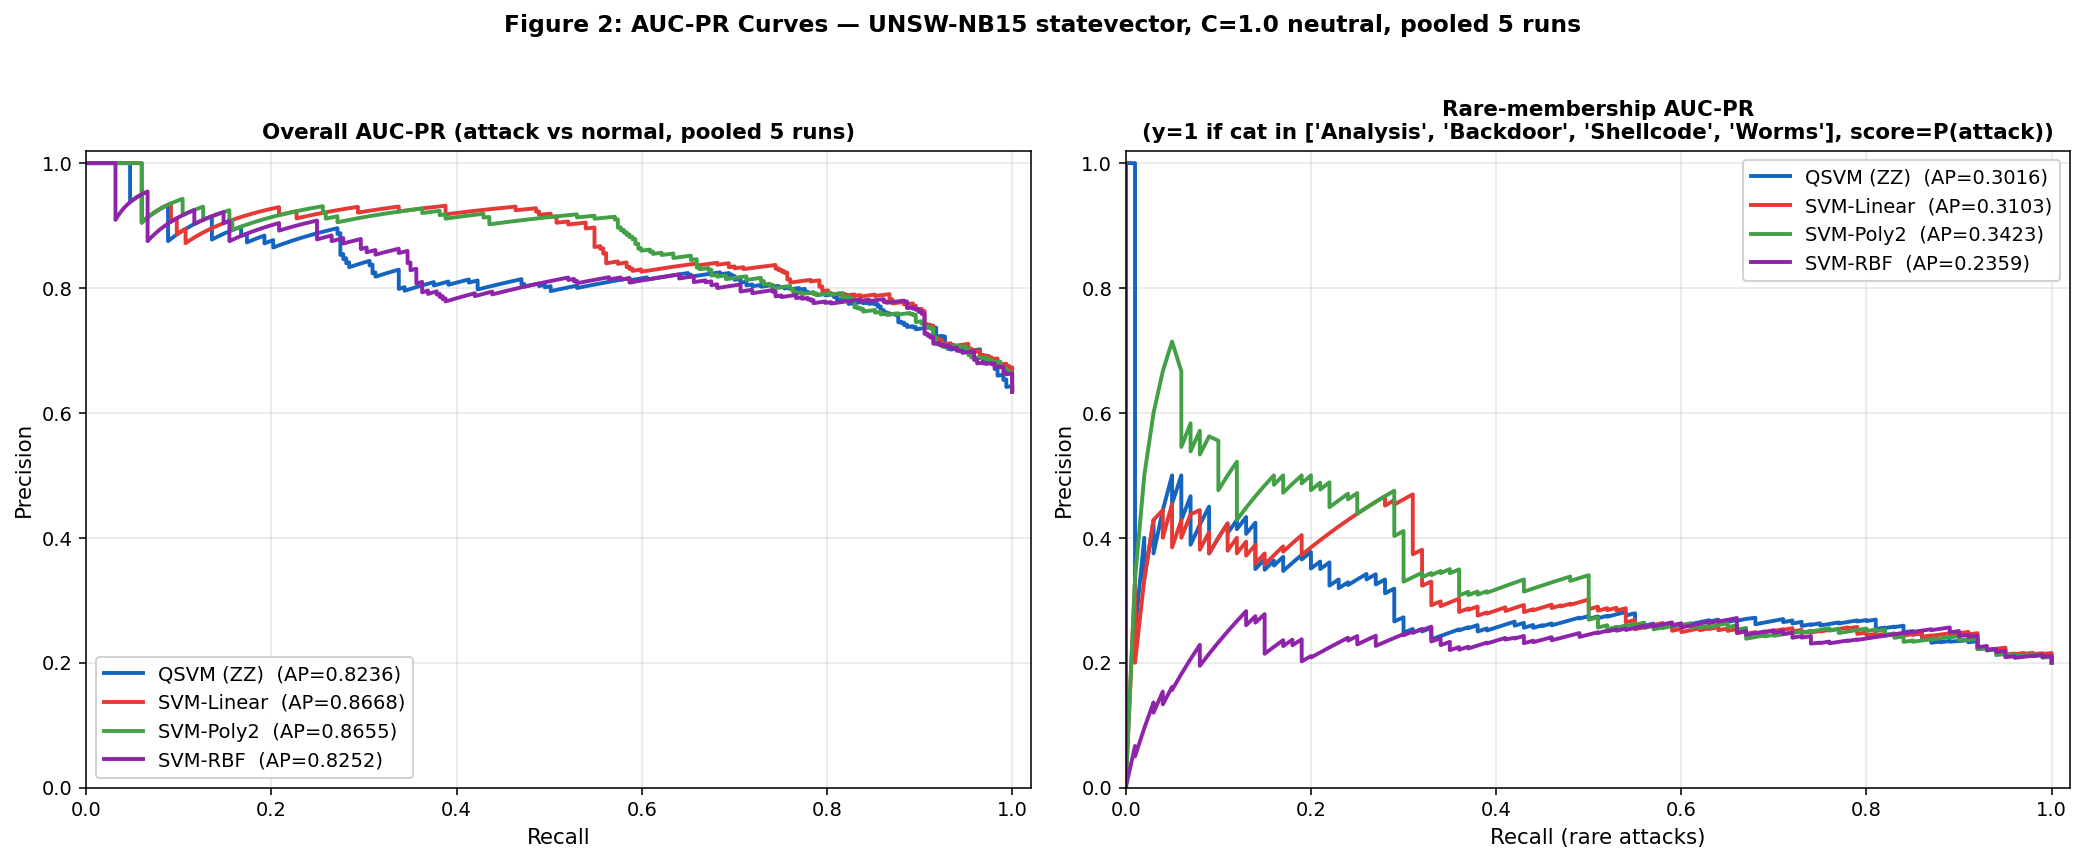

In [8]:
# Pool predictions across 5 runs
pooled = {k: {'y_binary': [], 'y_rare_member': [], 'prob': []} for k in KERNEL_NAMES}
for rid in RUN_IDS:
    res = all_results[rid]
    y_bin = np.array(res['y_test'])
    rare_mem = np.array(res['rare_mask'])  # 1 if rare cat
    for k in KERNEL_NAMES:
        prob = np.array(res['per_kernel'][k]['prob'])
        pooled[k]['y_binary'].extend(y_bin.tolist())
        pooled[k]['y_rare_member'].extend(rare_mem.tolist())
        pooled[k]['prob'].extend(prob.tolist())

fig2, axes = plt.subplots(1, 2, figsize=(15, 6))

# Overall AUC-PR (left)
for k in KERNEL_NAMES:
    y_t = np.array(pooled[k]['y_binary'])
    p   = np.array(pooled[k]['prob'])
    prec, rec, _ = precision_recall_curve(y_t, p)
    ap = average_precision_score(y_t, p)
    axes[0].plot(rec, prec, color=COLORS[k], linewidth=2,
                 label=f'{DISPLAY_NAMES[k]}  (AP={ap:.4f})')
axes[0].set_xlabel('Recall', fontsize=11)
axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title('Overall AUC-PR (attack vs normal, pooled 5 runs)',
                  fontsize=11, fontweight='bold')
axes[0].legend(loc='lower left', framealpha=0.9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 1.02); axes[0].set_ylim(0, 1.02)

# Rare-membership AUC-PR (right)
for k in KERNEL_NAMES:
    y_t = np.array(pooled[k]['y_rare_member'])
    p   = np.array(pooled[k]['prob'])
    prec, rec, _ = precision_recall_curve(y_t, p)
    ap = average_precision_score(y_t, p)
    axes[1].plot(rec, prec, color=COLORS[k], linewidth=2,
                 label=f'{DISPLAY_NAMES[k]}  (AP={ap:.4f})')
axes[1].set_xlabel('Recall (rare attacks)', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title(f'Rare-membership AUC-PR\n(y=1 if cat in {RARE_CATS}, score=P(attack))',
                  fontsize=11, fontweight='bold')
axes[1].legend(loc='upper right', framealpha=0.9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 1.02); axes[1].set_ylim(0, 1.02)

plt.suptitle(f'Figure 2: AUC-PR Curves — UNSW-NB15 statevector, C=1.0 neutral, pooled 5 runs',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
fig2_path = f'{REPORTS_DIR}/c5_auc_pr_curves.png'
fig2.savefig(fig2_path, dpi=140, bbox_inches='tight')
plt.close(fig2)
print(f'Saved: {fig2_path}')
display(Image(fig2_path))


## 8. Figure 3 — Margin distribution QSVM vs RBF on rare samples (KDE)

Saved: ../reports_unsw/c5_margin_distribution.png
Cohen's d (QSVM vs RBF, rare margin) = -0.2439  →  small (RBF > QSVM)


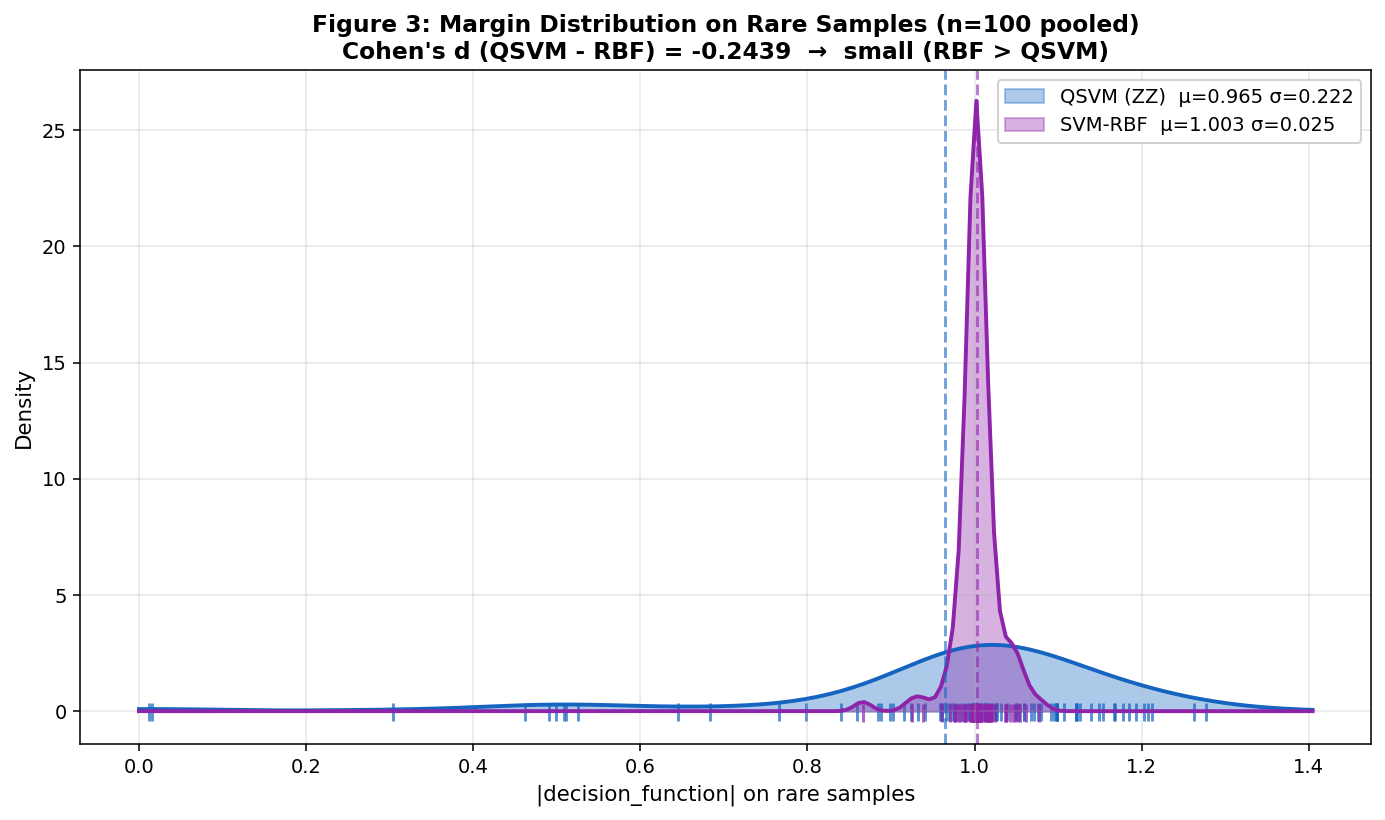

In [9]:
# Pool rare margins across 5 runs
q_margins = []
r_margins = []
for rid in RUN_IDS:
    q_margins.extend(all_results[rid]['per_kernel']['quantum']['rare_margin'])
    r_margins.extend(all_results[rid]['per_kernel']['rbf']['rare_margin'])
q_margins = np.array(q_margins)
r_margins = np.array(r_margins)

fig3, ax3 = plt.subplots(figsize=(10, 6))

# KDE if enough samples, else histogram
xmax = max(q_margins.max(), r_margins.max()) * 1.1 if len(q_margins) > 0 else 1.0
xs = np.linspace(0, xmax, 200)

for vals, k_name, color in [(q_margins, 'quantum', COLORS['quantum']),
                             (r_margins, 'rbf', COLORS['rbf'])]:
    if len(vals) >= 5 and vals.std() > 1e-9:
        kde = gaussian_kde(vals)
        ax3.fill_between(xs, kde(xs), alpha=0.35, color=color,
                         label=f'{DISPLAY_NAMES[k_name]}  μ={vals.mean():.3f} σ={vals.std():.3f}')
        ax3.plot(xs, kde(xs), color=color, linewidth=2)
    ax3.scatter(vals, np.full(len(vals), -0.05 if k_name=='quantum' else -0.1),
                color=color, marker='|', s=80, alpha=0.7)

ax3.axvline(q_margins.mean(), color=COLORS['quantum'], linestyle='--', alpha=0.6)
ax3.axvline(r_margins.mean(), color=COLORS['rbf'], linestyle='--', alpha=0.6)

d_val = cohens_d(q_margins, r_margins)
ax3.set_xlabel('|decision_function| on rare samples', fontsize=11)
ax3.set_ylabel('Density', fontsize=11)
ax3.set_title(f'Figure 3: Margin Distribution on Rare Samples (n={len(q_margins)} pooled)\n'
              f"Cohen's d (QSVM - RBF) = {d_val:+.4f}  →  {cohens_d_interpretation(d_val)}",
              fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', framealpha=0.9)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
fig3_path = f'{REPORTS_DIR}/c5_margin_distribution.png'
fig3.savefig(fig3_path, dpi=140, bbox_inches='tight')
plt.close(fig3)
print(f'Saved: {fig3_path}')
print(f"Cohen's d (QSVM vs RBF, rare margin) = {d_val:+.4f}  →  {cohens_d_interpretation(d_val)}")
display(Image(fig3_path))


## 9. Figure 4 — Per-group accuracy bar chart (4 rare cats × 4 kernels)

Saved: ../reports_unsw/c5_per_group_accuracy.png


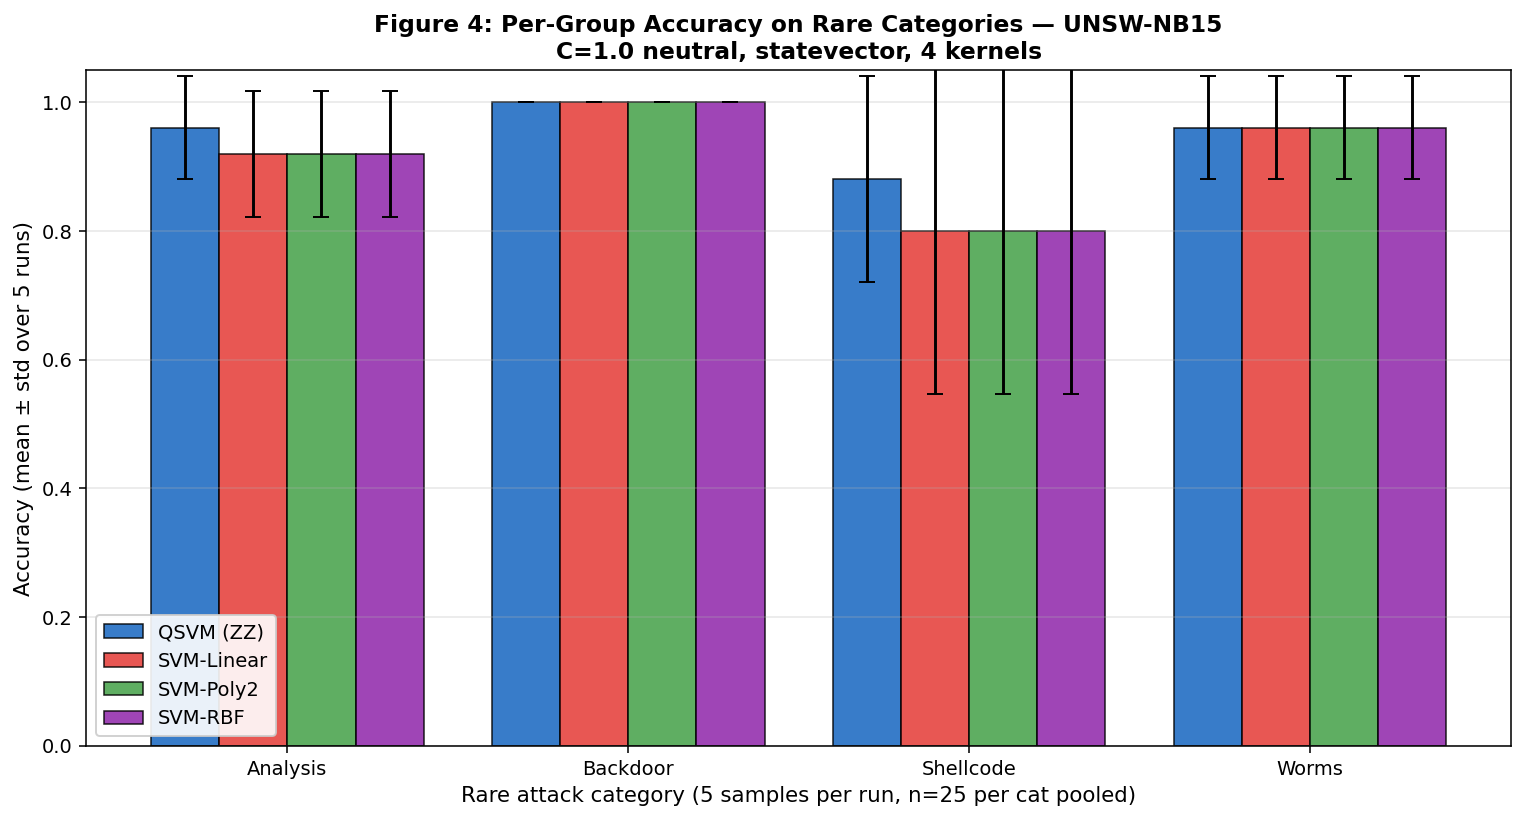

In [10]:
fig4, ax4 = plt.subplots(figsize=(11, 6))
x = np.arange(len(RARE_CATS))
width = 0.20

for idx, k in enumerate(KERNEL_NAMES):
    means = [summary[k]['per_group_acc_mean'][cat] for cat in RARE_CATS]
    # std across 5 runs
    stds = []
    for cat in RARE_CATS:
        vals = [all_results[rid]['per_kernel'][k]['per_group_acc'][cat] for rid in RUN_IDS]
        stds.append(float(np.std(vals)))
    ax4.bar(x + (idx - 1.5) * width, means, width, yerr=stds,
            label=DISPLAY_NAMES[k], color=COLORS[k], alpha=0.85,
            capsize=4, edgecolor='black', linewidth=0.8)

ax4.set_xticks(x); ax4.set_xticklabels(RARE_CATS)
ax4.set_xlabel('Rare attack category (5 samples per run, n=25 per cat pooled)', fontsize=11)
ax4.set_ylabel('Accuracy (mean ± std over 5 runs)', fontsize=11)
ax4.set_title(f'Figure 4: Per-Group Accuracy on Rare Categories — UNSW-NB15\n'
              f'C=1.0 neutral, statevector, 4 kernels',
              fontsize=12, fontweight='bold')
ax4.grid(True, axis='y', alpha=0.3)
ax4.legend(loc='best', framealpha=0.9)
ax4.set_ylim(0, 1.05)
plt.tight_layout()
fig4_path = f'{REPORTS_DIR}/c5_per_group_accuracy.png'
fig4.savefig(fig4_path, dpi=140, bbox_inches='tight')
plt.close(fig4)
print(f'Saved: {fig4_path}')
display(Image(fig4_path))


## 10. Statistical tests — Cohen's d (rare margin) + McNemar per rare cat

In [11]:
# ── Cohen's d per run + combined (QSVM vs RBF on rare margin) ──
cohen_per_run = []
all_q, all_r = [], []
for rid in RUN_IDS:
    q = np.array(all_results[rid]['per_kernel']['quantum']['rare_margin'])
    r = np.array(all_results[rid]['per_kernel']['rbf']['rare_margin'])
    d = cohens_d(q, r)
    cohen_per_run.append({
        'run': rid, 'd': d,
        'interpretation': cohens_d_interpretation(d),
        'n_rare': len(q),
    })
    all_q.extend(q.tolist())
    all_r.extend(r.tolist())
    print(f'  run_{rid}: d={d:+.4f}  ({cohens_d_interpretation(d)})  n_rare={len(q)}')

combined_d = cohens_d(np.array(all_q), np.array(all_r))
print(f'\n=== Cohen\'s d COMBINED (pooled n_rare={len(all_q)}) ===')
print(f'  d = {combined_d:+.4f}  →  {cohens_d_interpretation(combined_d)}')

cohen_payload = {
    'per_run':         cohen_per_run,
    'combined_d':      combined_d,
    'interpretation':  cohens_d_interpretation(combined_d),
    'pooled_n_rare':   len(all_q),
    'qsvm_margin_mean': float(np.mean(all_q)),
    'qsvm_margin_std':  float(np.std(all_q)),
    'rbf_margin_mean':  float(np.mean(all_r)),
    'rbf_margin_std':   float(np.std(all_r)),
}

# ── McNemar per rare cat (pool b/c across 5 runs, exact binomial) ──
print(f'\n=== McNemar per rare cat (QSVM vs RBF, pooled 5 runs) ===')
mcnemar_per_cat = {}
for cat in RARE_CATS:
    total_b, total_c = 0, 0
    n_total_cat = 0
    for rid in RUN_IDS:
        res = all_results[rid]
        cat_test = np.array(res['cat_test'])
        mask = (cat_test == cat)
        if mask.sum() == 0: continue
        y_t = np.array(res['y_test'])[mask]
        y_q = np.array(res['per_kernel']['quantum']['y_pred'])[mask]
        y_r = np.array(res['per_kernel']['rbf']['y_pred'])[mask]
        b, c, _ = mcnemar_exact(y_t, y_q, y_r)
        total_b += b; total_c += c
        n_total_cat += int(mask.sum())
    if total_b + total_c == 0:
        p_combined = 1.0
    else:
        p_combined = float(binomtest(min(total_b, total_c), n=total_b+total_c, p=0.5).pvalue)
    mcnemar_per_cat[cat] = {
        'b': total_b, 'c': total_c, 'n_samples': n_total_cat,
        'p_value': p_combined,
        'b_meaning': 'QSVM wrong & RBF correct',
        'c_meaning': 'QSVM correct & RBF wrong',
    }
    print(f'  {cat:>10s} (n={n_total_cat:>2d}): b={total_b:>2d}, c={total_c:>2d}, p={p_combined:.4f}')


  run_1: d=-0.4304  (small (RBF > QSVM))  n_rare=20
  run_2: d=-0.3780  (small (RBF > QSVM))  n_rare=20
  run_3: d=-0.4290  (small (RBF > QSVM))  n_rare=20
  run_4: d=+1.0173  (large (QSVM > RBF))  n_rare=20
  run_5: d=-0.3989  (small (RBF > QSVM))  n_rare=20

=== Cohen's d COMBINED (pooled n_rare=100) ===
  d = -0.2439  →  small (RBF > QSVM)

=== McNemar per rare cat (QSVM vs RBF, pooled 5 runs) ===
    Analysis (n=25): b= 0, c= 1, p=1.0000
    Backdoor (n=25): b= 0, c= 0, p=1.0000
   Shellcode (n=25): b= 0, c= 2, p=0.5000
       Worms (n=25): b= 0, c= 0, p=1.0000


## 11. Export `c5_results.json`

In [12]:
# Build per_run (drop large arrays — prob/y_pred/rare_margin)
per_run_payload = []
for rid in RUN_IDS:
    res = all_results[rid]
    entry = {'run': rid}
    for k in KERNEL_NAMES:
        m = res['per_kernel'][k]
        entry[k] = {
            'C':              m['C'],
            'f1':             m['f1'],
            'precision':      m['precision'],
            'recall':         m['recall'],
            'accuracy':       m['accuracy'],
            'ece_rare':       m['ece_rare'],
            'auc_pr_overall': m['auc_pr_overall'],
            'auc_pr_rare':    m['auc_pr_rare'],
            'per_group_acc':  m['per_group_acc'],
            'rare_margin_mean': m['rare_margin_mean'],
            'rare_margin_std':  m['rare_margin_std'],
            'n_rare_test':    m['n_rare_test'],
        }
    per_run_payload.append(entry)

metadata_payload = {
    'regime':              'statevector',
    'backend':             'FidelityStatevectorKernel',
    'n_runs':              len(RUN_IDS),
    'C_strategy':          C_STRATEGY,
    'C_by_kernel':         {k: float(C_BY_KERNEL[k]) for k in KERNEL_NAMES},
    'cache_reused_from':   MULTIRUN_CACHE,
    'compared_against_nsl': NSL_C5_JSON,
    'rare_categories':     RARE_CATS,
    'n_rare_per_test':     20,
    'ece_n_bins':          ECE_N_BINS,
    'config_tag':          CONFIG_TAG,
    'k_select':            K_SELECT,
    'pca_n':               PCA_N,
    'poly_degree':         POLY_DEGREE,
    'kernels':             KERNEL_NAMES,
    'platt_scaling':       'SVC(probability=True) internal 5-fold CV',
    'date':                datetime.date.today().isoformat(),
    'reports':             [
        f'{REPORTS_DIR}/c5_calibration_curves.png',
        f'{REPORTS_DIR}/c5_auc_pr_curves.png',
        f'{REPORTS_DIR}/c5_margin_distribution.png',
        f'{REPORTS_DIR}/c5_per_group_accuracy.png',
    ],
    'rationale': (
        '1.7 measures calibration + rare-class metrics for QSVM vs classical kernels '
        'on UNSW. C=1.0 neutral (consistent with 1.4a-redo/1.5-redo). Reuses quantum '
        'kernel cache 100% from multirun/. Goal: check if QSVM has an advantage angle '
        'beyond raw F1 (NSL-KDD pattern: QSVM ECE_rare=0.434 < RBF=0.471).'
    ),
}

payload = {
    'per_run':              per_run_payload,
    'summary':              summary,
    'cohen_d_qsvm_vs_rbf':  cohen_payload,
    'mcnemar_per_rare_cat': mcnemar_per_cat,
    'metadata':             metadata_payload,
}

with open(RESULTS_JSON, 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)
print(f'[SAVED] {RESULTS_JSON}  ({os.path.getsize(RESULTS_JSON)} bytes)')
print(f'  per_run    : {len(per_run_payload)} runs × {len(KERNEL_NAMES)} kernels')
print(f'  cohen_d    : combined={cohen_payload["combined_d"]:+.4f} ({cohen_payload["interpretation"]})')
print(f'  mcnemar    : {len(mcnemar_per_cat)} rare cats')


[SAVED] ../models_unsw/c5_results.json  (17565 bytes)
  per_run    : 5 runs × 4 kernels
  cohen_d    : combined=-0.2439 (small (RBF > QSVM))
  mcnemar    : 4 rare cats


## 12. Bonus — UNSW vs NSL-KDD comparison (rare metrics)

So sánh trực tiếp ECE_rare, AUC-PR overall, Cohen's d giữa NSL-KDD (đã có) và UNSW (1.7 vừa tính). Mục đích: xem QSVM advantage trên rare có **generalize** từ NSL sang UNSW không.

In [13]:
# Load NSL-KDD C5 reference
nsl_path = NSL_C5_JSON
if os.path.exists(nsl_path):
    with open(nsl_path, 'r', encoding='utf-8') as f:
        nsl = json.load(f)
    nsl_ece     = nsl['calibration']
    nsl_stats   = nsl['statistical_tests']
    # NSL không có "AUC-PR rare overall" — dùng pr_auc_per_class U2R+R2L average
    nsl_pr_rare = (nsl['pr_auc_per_class']['U2R']['QSVM'] + nsl['pr_auc_per_class']['R2L']['QSVM']) / 2
    nsl_pr_rare_rbf = (nsl['pr_auc_per_class']['U2R']['SVM-RBF'] + nsl['pr_auc_per_class']['R2L']['SVM-RBF']) / 2
    print(f'[OK] Loaded NSL-KDD C5 reference: {nsl_path}')
else:
    nsl_ece = nsl_stats = None
    print(f'[WARN] NSL C5 reference not found at {nsl_path}')

# UNSW summary
u_q   = summary['quantum']; u_rbf = summary['rbf']
u_d   = cohen_payload['combined_d']

print()
print('=' * 110)
print('  BONUS: UNSW vs NSL-KDD comparison — rare-class calibration & ranking metrics')
print('=' * 110)
print(f'  {"Metric":<28}  {"NSL-KDD QSVM":>13}  {"NSL-KDD RBF":>13}  '
      f'{"UNSW QSVM":>14}  {"UNSW RBF":>14}  {"Verdict":>16}')
print('  ' + '-' * 108)

if nsl_ece is not None:
    # ECE_rare: lower = better
    nsl_ece_q = nsl_ece['QSVM']['ece_rare']; nsl_ece_r = nsl_ece['SVM-RBF']['ece_rare']
    u_ece_q   = u_q['ece_rare_mean'];        u_ece_r   = u_rbf['ece_rare_mean']
    verdict_nsl = 'QSVM ✓' if nsl_ece_q < nsl_ece_r else 'RBF ✓'
    verdict_u   = 'QSVM ✓' if u_ece_q   < u_ece_r   else 'RBF ✓'
    print(f'  {"ECE_rare (lower better)":<28}  {nsl_ece_q:>13.4f}  {nsl_ece_r:>13.4f}  '
          f'{u_ece_q:>14.4f}  {u_ece_r:>14.4f}  NSL:{verdict_nsl} UNSW:{verdict_u}')

    # AUC-PR rare avg (U2R+R2L for NSL; rare-membership for UNSW)
    u_pr_q = u_q['auc_pr_rare_mean']; u_pr_r = u_rbf['auc_pr_rare_mean']
    verdict_nsl_pr = 'QSVM ✓' if nsl_pr_rare > nsl_pr_rare_rbf else 'RBF ✓'
    verdict_u_pr   = 'QSVM ✓' if u_pr_q > u_pr_r else 'RBF ✓'
    print(f'  {"AUC-PR rare (higher)":<28}  {nsl_pr_rare:>13.4f}  {nsl_pr_rare_rbf:>13.4f}  '
          f'{u_pr_q:>14.4f}  {u_pr_r:>14.4f}  NSL:{verdict_nsl_pr} UNSW:{verdict_u_pr}')

    # Cohen's d
    nsl_d = nsl_stats['cohens_d_margin_rare']
    print(f'  {"Cohen\'s d (QSVM-RBF)":<28}  {nsl_d:>13.4f}  {"-":>13}  '
          f'{u_d:>14.4f}  {"-":>14}  '
          f'NSL:{"QSVM>" if nsl_d>0 else "RBF>"} UNSW:{"QSVM>" if u_d>0 else "RBF>"}')

print('  ' + '-' * 108)
print(f'  Cohen\'s d interpretation:')
print(f'    NSL: d = {nsl_stats["cohens_d_margin_rare"]:+.4f}  ({cohens_d_interpretation(nsl_stats["cohens_d_margin_rare"])})')
print(f'    UNSW: d = {u_d:+.4f}  ({cohens_d_interpretation(u_d)})')
print('=' * 110)

# Save bonus comparison vào JSON
if nsl_ece is not None:
    payload['comparison_vs_nsl_kdd'] = {
        'nsl_path': nsl_path,
        'ece_rare':       {'nsl_qsvm': nsl_ece['QSVM']['ece_rare'], 'nsl_rbf': nsl_ece['SVM-RBF']['ece_rare'],
                           'unsw_qsvm': u_q['ece_rare_mean'],       'unsw_rbf': u_rbf['ece_rare_mean']},
        'auc_pr_rare':    {'nsl_qsvm': nsl_pr_rare,                 'nsl_rbf': nsl_pr_rare_rbf,
                           'unsw_qsvm': u_q['auc_pr_rare_mean'],    'unsw_rbf': u_rbf['auc_pr_rare_mean']},
        'cohens_d_rare':  {'nsl': nsl_stats['cohens_d_margin_rare'], 'unsw': u_d},
        'note':           ('NSL AUC-PR rare = avg(U2R, R2L) per_class; '
                           'UNSW AUC-PR rare = rare-membership scoring (Analysis+Backdoor+Shellcode+Worms vs others).'),
    }
    with open(RESULTS_JSON, 'w', encoding='utf-8') as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)
    print(f'\n[UPDATED] {RESULTS_JSON} (appended comparison_vs_nsl_kdd)')


[OK] Loaded NSL-KDD C5 reference: ../data/processed_data/c5_results.json

  BONUS: UNSW vs NSL-KDD comparison — rare-class calibration & ranking metrics
  Metric                         NSL-KDD QSVM    NSL-KDD RBF       UNSW QSVM        UNSW RBF           Verdict
  ------------------------------------------------------------------------------------------------------------
  ECE_rare (lower better)              0.4337         0.4707          0.1935          0.2047  NSL:QSVM ✓ UNSW:QSVM ✓
  AUC-PR rare (higher)                 0.0617         0.0571          0.3355          0.2463  NSL:QSVM ✓ UNSW:QSVM ✓
  Cohen's d (QSVM-RBF)                -0.6805              -         -0.2439               -  NSL:RBF> UNSW:RBF>
  ------------------------------------------------------------------------------------------------------------
  Cohen's d interpretation:
    NSL: d = -0.6805  (medium (RBF > QSVM))
    UNSW: d = -0.2439  (small (RBF > QSVM))

[UPDATED] ../models_unsw/c5_results.json (appended

## 13. Summary

In [14]:
print('=' * 90)
print('  UNSW-NB15 — C5 CONFIDENCE CALIBRATION MULTI-RUN (1.7, C=1.0 NEUTRAL, STATEVECTOR)')
print('=' * 90)
print(f'  CONFIG_TAG : {CONFIG_TAG}')
print(f'  C_STRATEGY : {C_STRATEGY}')
print(f'  Cache reuse: 100% từ {MULTIRUN_CACHE}')
print(f'  Runs       : {len(RUN_IDS)} | Kernels: {KERNEL_NAMES}')
print(f'  Rare cats  : {RARE_CATS}  (5/cat/run × 5 runs = 25/cat pooled)')
print()

print(f'  {"Kernel":>10}  {"F1":>14}  {"ECE_rare ↓":>14}  {"AUC-PR_rare ↑":>15}  {"AUC-PR_all ↑":>15}')
print('  ' + '-' * 80)
for k in KERNEL_NAMES:
    s = summary[k]
    print(f'  {k:>10}  {s["f1_mean"]:.4f}±{s["f1_std"]:.3f}  '
          f'{s["ece_rare_mean"]:.4f}±{s["ece_rare_std"]:.3f}  '
          f'{s["auc_pr_rare_mean"]:.4f}±{s["auc_pr_rare_std"]:.3f}  '
          f'{s["auc_pr_overall_mean"]:.4f}±{s["auc_pr_overall_std"]:.3f}')

print()
print(f'  Cohen\'s d (QSVM vs RBF, pooled rare margin n={cohen_payload["pooled_n_rare"]}):')
print(f'    d = {cohen_payload["combined_d"]:+.4f}  →  {cohen_payload["interpretation"]}')

print()
print(f'  Per-group accuracy (mean across 5 runs):')
print(f'  {"Cat":>10}  ' + '  '.join([f'{DISPLAY_NAMES[k]:>10}' for k in KERNEL_NAMES]))
for cat in RARE_CATS:
    vals = [summary[k]['per_group_acc_mean'][cat] for k in KERNEL_NAMES]
    print(f'  {cat:>10}  ' + '  '.join([f'{v:>10.3f}' for v in vals]))

print()
print(f'  McNemar per cat (QSVM vs RBF, pooled b/c):')
for cat, m in mcnemar_per_cat.items():
    sig = ' (sig)' if m['p_value'] < 0.05 else ''
    print(f'    {cat:>10}: b={m["b"]:>2}, c={m["c"]:>2}, p={m["p_value"]:.4f}{sig}')

# Verdict
print()
qsvm_best = []
for metric, k_key, lower_better in [
    ('ECE_rare', 'ece_rare_mean', True),
    ('AUC-PR_rare', 'auc_pr_rare_mean', False),
    ('AUC-PR_all', 'auc_pr_overall_mean', False),
]:
    vals = {k: summary[k][k_key] for k in KERNEL_NAMES}
    best = min(vals, key=vals.get) if lower_better else max(vals, key=vals.get)
    if best == 'quantum':
        qsvm_best.append(metric)
print(f'  ⇒ QSVM dẫn đầu ở: {qsvm_best if qsvm_best else "không metric nào"}')
print('=' * 90)


  UNSW-NB15 — C5 CONFIDENCE CALIBRATION MULTI-RUN (1.7, C=1.0 NEUTRAL, STATEVECTOR)
  CONFIG_TAG : r2_full_k35_p4_cv5_sf1_run1
  C_STRATEGY : neutral_C1_no_retune
  Cache reuse: 100% từ ../models_unsw/qsvm_cache/multirun
  Runs       : 5 | Kernels: ['quantum', 'linear', 'poly', 'rbf']
  Rare cats  : ['Analysis', 'Backdoor', 'Shellcode', 'Worms']  (5/cat/run × 5 runs = 25/cat pooled)

      Kernel              F1      ECE_rare ↓    AUC-PR_rare ↑     AUC-PR_all ↑
  --------------------------------------------------------------------------------
     quantum  0.7977±0.022  0.1935±0.053  0.3355±0.089  0.8651±0.038
      linear  0.8129±0.024  0.1824±0.045  0.3449±0.046  0.8935±0.022
        poly  0.7971±0.018  0.1928±0.044  0.4079±0.083  0.8853±0.024
         rbf  0.8015±0.021  0.2047±0.029  0.2463±0.029  0.8582±0.071

  Cohen's d (QSVM vs RBF, pooled rare margin n=100):
    d = -0.2439  →  small (RBF > QSVM)

  Per-group accuracy (mean across 5 runs):
         Cat   QSVM (ZZ)  SVM-Linear  